In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, f1_score, mean_absolute_error

def plot_preds_csv(csv_path, save_path=None, thr_binary=5.0, title=None):
    """
    Draws:
      - Top-left: Binary (≤thr vs >thr) GT vs Pred lines + misclassified points
      - Top-right: Binary confusion matrix + F1
      - Bottom-left: 4-class GT vs Pred lines + misclassified points
      - Bottom-right: 4-class confusion matrix + weighted F1

    Params
    ------
    csv_path : str or Path
      CSV with columns: patient_ID, <set_col>, target, prediction
      (extra cols are okay; if a column contains 'set' in its name and has 'test',
       rows are filtered to test only)
    save_path : str or Path or None
      If given, saves the figure; otherwise shows it.
    thr_binary : float
      PDFF threshold for binary split (default 5.0).
    title : str or None
      Optional super-title for the whole figure.
    """
    df = pd.read_csv(csv_path)

    # Optional: filter to test rows if a "set" column exists
    set_col = next((c for c in df.columns if 'set' in c.lower()), None)
    if set_col is not None:
        # keep rows marked as 'test' (case-insensitive)
        if df[set_col].astype(str).str.lower().isin(['test']).any():
            df = df[df[set_col].astype(str).str.lower() == 'test'].copy()

    # Ensure required columns exist
    for c in ['patient_ID', 'target', 'prediction']:
        if c not in df.columns:
            raise ValueError(f"Missing required column: '{c}' in {csv_path}")

    # Sort by patient_ID for stable plotting
    # (handle numeric IDs saved as strings)
    try:
        df['patient_ID_num'] = pd.to_numeric(df['patient_ID'], errors='coerce')
        df = df.sort_values(['patient_ID_num', 'patient_ID']).drop(columns=['patient_ID_num'])
    except Exception:
        df = df.sort_values('patient_ID')

    # ---------- helpers ----------
    def to_binary(x):
        # <= thr → 0, > thr → 1 (senin önceki binary kuralına uygun)
        return 0 if x <= thr_binary else 1

    def to_class4(x):
        # 4-class sınırları (senin kullandığın cutlar)
        if x < 6.4:
            return 0
        elif x < 16.3:
            return 1
        elif x < 20.7:
            return 2
        else:
            return 3

    # Compute labels
    df['Binary_GT']  = df['target'].apply(to_binary)
    df['Binary_Pred'] = df['prediction'].apply(to_binary)
    df['Class_GT']   = df['target'].apply(to_class4)
    df['Class_Pred'] = df['prediction'].apply(to_class4)

    # Metrics
    mae = mean_absolute_error(df['target'], df['prediction'])
    f1_bin = f1_score(df['Binary_GT'], df['Binary_Pred'], zero_division=0)
    f1_wgt = f1_score(df['Class_GT'], df['Class_Pred'], average='weighted', zero_division=0)

    # Misclassified masks
    mism_bin = df['Binary_GT'] != df['Binary_Pred']
    mism_cls = df['Class_GT']  != df['Class_Pred']

    # ---------- plotting ----------
    fig, axs = plt.subplots(2, 2, figsize=(18, 10))
    if title:
        fig.suptitle(title, fontsize=14, fontweight='bold', y=0.98)

    # x-axis as categorical index for nicer spacing
    x = range(len(df))
    labels = df['patient_ID'].astype(str).tolist()

    # Top-left: Binary line plot + misclassified
    axs[0, 0].plot(x, df['target'], label='GroundTruth', marker='o', color="#6ed659", markersize=5)
    axs[0, 0].plot(x, df['prediction'], label='Predicted', marker='x', color="#4c8ebd", markersize=5)
    axs[0, 0].scatter([xi for xi, m in zip(x, mism_bin) if m],
                      df.loc[mism_bin, 'prediction'],
                      color='crimson', label='Misclassified', zorder=5, s=40)
    axs[0, 0].axhline(y=thr_binary, color='red', linestyle='--', label=f'Threshold = {thr_binary:g}%')
    axs[0, 0].set_title(f"Binary (≤{thr_binary} vs >{thr_binary})  |  MAE: {mae:.2f}")
    axs[0, 0].set_ylabel("PDFF (%)")
    axs[0, 0].set_xticks(x)
    axs[0, 0].set_xticklabels(labels, rotation=90, fontsize=7)
    axs[0, 0].legend(fontsize=9)
    axs[0, 0].grid(True, linestyle='--', alpha=0.5)

    # Top-right: Binary confusion matrix
    cm_bin = confusion_matrix(df['Binary_GT'], df['Binary_Pred'], labels=[0, 1])
    disp_bin = ConfusionMatrixDisplay(confusion_matrix=cm_bin, display_labels=["≤thr", ">thr"])
    disp_bin.plot(ax=axs[0, 1], cmap='YlGnBu', colorbar=False, values_format='d')
    axs[0, 1].set_title(f"Confusion Matrix (Binary)\nF1: {f1_bin:.2f}")

    # Bottom-left: 4-class line plot + misclassified
    axs[1, 0].plot(x, df['target'], label='GroundTruth', marker='o', color="#6ed659", markersize=5)
    axs[1, 0].plot(x, df['prediction'], label='Predicted', marker='x', color="#4c8ebd", markersize=5)
    axs[1, 0].scatter([xi for xi, m in zip(x, mism_cls) if m],
                      df.loc[mism_cls, 'prediction'],
                      color='crimson', label='Misclassified', zorder=5, s=40)
    for thresh in [6.4, 16.3, 20.7]:
        axs[1, 0].axhline(y=thresh, color='red', linestyle='--')
    axs[1, 0].set_title(f"4-Class  |  MAE: {mae:.2f}")
    axs[1, 0].set_xlabel("Patient ID")
    axs[1, 0].set_ylabel("PDFF (%)")
    axs[1, 0].set_xticks(x)
    axs[1, 0].set_xticklabels(labels, rotation=90, fontsize=7)
    axs[1, 0].legend(fontsize=9)
    axs[1, 0].grid(True, linestyle='--', alpha=0.5)

    # Bottom-right: 4-class confusion matrix
    cm_cls = confusion_matrix(df['Class_GT'], df['Class_Pred'], labels=[0, 1, 2, 3])
    disp_cls = ConfusionMatrixDisplay(confusion_matrix=cm_cls, display_labels=["<6.4", "6.4–16.3", "16.3–20.7", "≥20.7"])
    disp_cls.plot(ax=axs[1, 1], cmap='YlGnBu', colorbar=False, values_format='d')
    axs[1, 1].set_title(f"Confusion Matrix (4-Class)\nweighted F1: {f1_wgt:.2f}")

    plt.tight_layout()

    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        plt.close()
    else:
        plt.show()

    return {
        "mae": mae,
        "f1_binary": f1_bin,
        "f1_weighted_4class": f1_wgt,
        "cm_binary": cm_bin,
        "cm_4class": cm_cls
    }


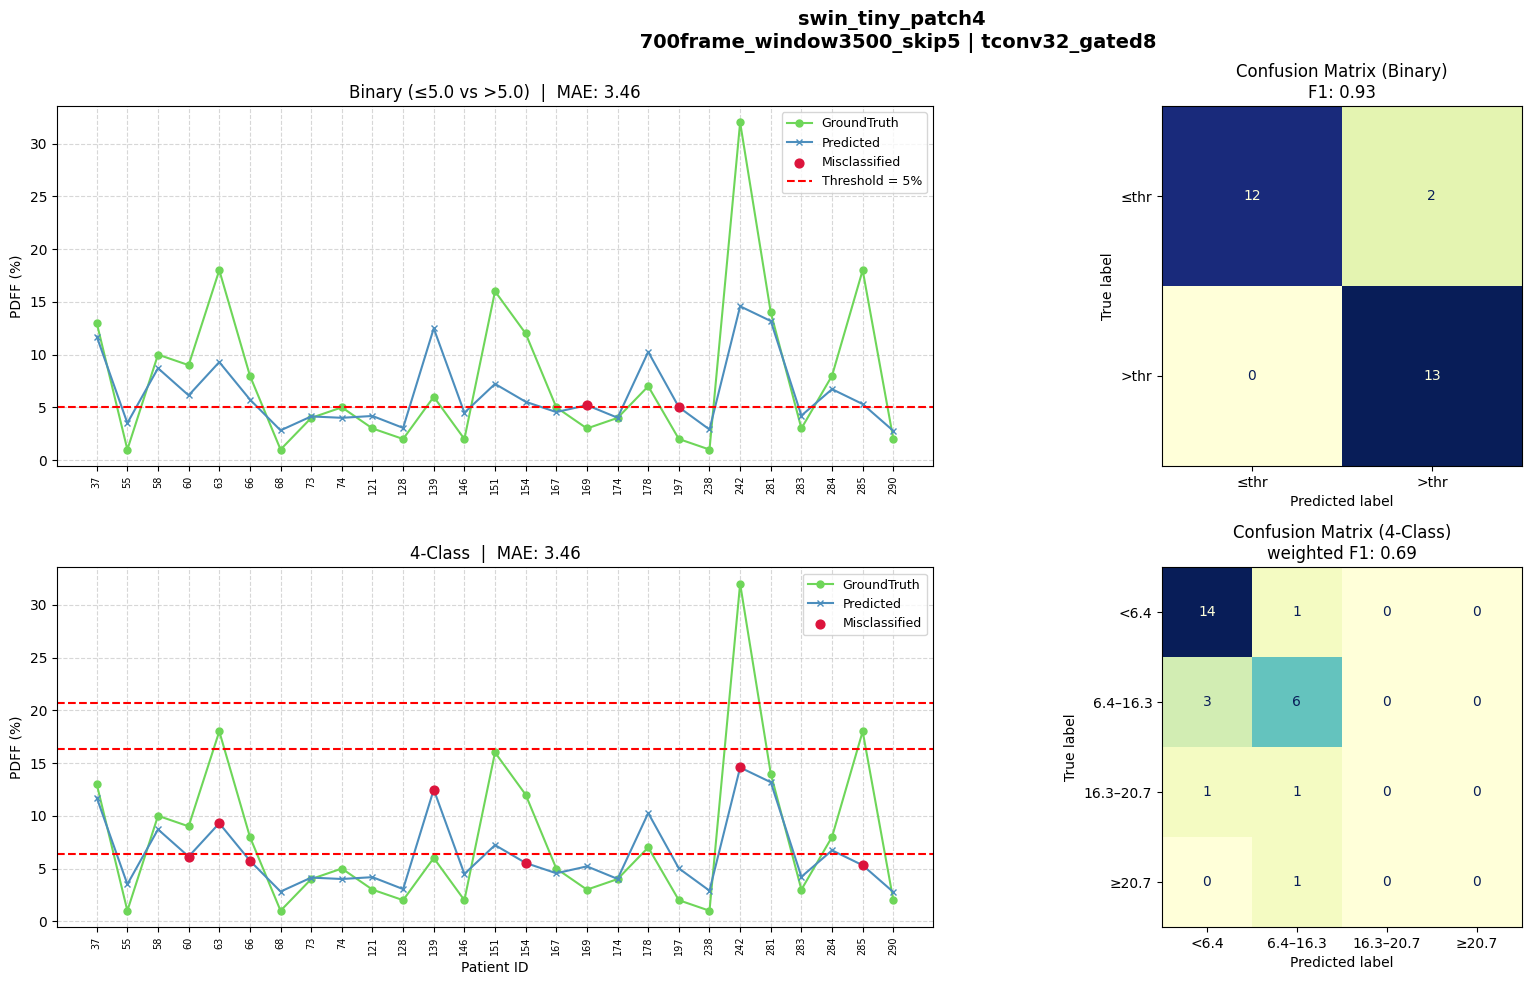

{'mae': 3.458222374074074,
 'f1_binary': 0.9285714285714286,
 'f1_weighted_4class': 0.6936026936026936,
 'cm_binary': array([[12,  2],
        [ 0, 13]]),
 'cm_4class': array([[14,  1,  0,  0],
        [ 3,  6,  0,  0],
        [ 1,  1,  0,  0],
        [ 0,  1,  0,  0]])}

In [32]:
csv_path = "/research/projects/Sahika/projects/liver_PDFF/clean_code/runs/swin_tiny_patch4_window7_224.ms_in1k_gelu/700frame_window3500_skip5/tconv32_gated8/test_predicted_true_values.csv"

plot_preds_csv(
    csv_path,
    save_path=None,            # dosyaya kaydetmek istersen bir yol ver
    thr_binary=5.0,
    title="swin_tiny_patch4 \n 700frame_window3500_skip5 | tconv32_gated8"
)
